# Wrangling whole directories: trade and bbo



In [1]:


import os
os.environ['POLARS_AUTO_NEW_STREAMING'] = '1'


import polars as pl
import pandas as pd

import numpy as np

import os

dirData_raw = "/data/extraction/TRTH/raw/equities/US/"
dirData_clean = dirData_raw.replace("raw","clean")
if not os.path.isdir(dirData_clean):
    os.makedirs(dirData_clean)


ticker = "SPY.P"

## Column format sanity check

In [2]:
import os

def scan_file(file):
    print(file)
    try:
        dtypes = pl.scan_parquet(file).dtypes
    except:
        os.rename(file,file+"_bad")
        return None
    
    return dtypes

In [3]:
import glob 
import os
import pdb

def find_fix_dtype(dirData,pattern="*.parquet"):
    allfiles = glob.glob(dirData+"/"+pattern)
    allfiles.sort()
    assert(len(allfiles)>0)

    all_dtypes = []
    for myfile in allfiles:
    # print(myfile)
        all_dtypes.append(pl.scan_parquet(myfile).dtypes)
                        
    dtypes_DF = pd.DataFrame(all_dtypes)
    dtypes_DF = dtypes_DF.astype(str)                 # value_counts() require objects that can be ordered.
    #print(dtypes_DF)

    most_common_data_types = pd.DataFrame(dtypes_DF.value_counts()).iloc[0].name
    print(most_common_data_types)

    for idx in range(len(all_dtypes)):
        my_dtypes=all_dtypes[idx]
        my_dtypes=[str(x) for x in my_dtypes]

        all_good = all([a==b for a,b in zip(my_dtypes,most_common_data_types)])
        if not all_good:

            df = pl.read_parquet(allfiles[idx])
            if df.shape[0]==0:
                os.rename(allfiles[idx],allfiles[idx]+"-bad")
                continue
            try:
                print("Fixing ",allfiles[idx])
                print(all_good)
                for idx_c in range(len(most_common_data_types)):
                    c = df.columns[idx_c]
                    dtype_new = most_common_data_types[idx_c]
                    if(dtype_new=="Float64"):
                        df = df.with_columns(pl.col(c).cast(pl.Float64,strict=False))
                    if(dtype_new=="Float32"):
                        df = df.with_columns(pl.col(c).cast(pl.Float32,strict=False))
                    if(dtype_new=="Int64"):
                        df = df.with_columns(pl.col(c).cast(pl.Int64,strict=False))
                    if(dtype_new=="Int32"):
                        df = df.with_columns(pl.col(c).cast(pl.Int32,strict=False))
                    if(dtype_new=="String"):
                        df = df.with_columns(pl.col(c).cast(pl.Utf8,strict=False))
                df = df.drop_nulls()
                df.write_parquet(allfiles[idx])
            except Exception as e:
                print("Failed to fix ",allfiles[idx],": ",e)
                pdb.set_trace()

             #   os.rename(allfiles[idx],allfiles[idx]+"-bad")



In [4]:

find_fix_dtype(dirData_raw+"/bbo/"+ticker)

find_fix_dtype(dirData_raw+"/trade/"+ticker)


/tmp/ipykernel_727881/1099525844.py:13: PerformanceWarning: Determining the data types of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().dtypes()` to get the data types without this warning.
  all_dtypes.append(pl.scan_parquet(myfile).dtypes)


('Float64', 'Float64', 'Int32', 'Float64', 'Int32')


/tmp/ipykernel_727881/1099525844.py:13: PerformanceWarning: Determining the data types of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().dtypes()` to get the data types without this warning.
  all_dtypes.append(pl.scan_parquet(myfile).dtypes)


('Float64', 'Float64', 'Int32', 'String', 'String')


## Trade and bbo wrangling functions that allow directory-wise scan_parquet

In [5]:
def wrangle_trade(DF,
            tz_exchange="America/New_York",
            only_non_special_trades=True,
            only_regular_trading_hours=True,
            merge_sub_trades=True,
            keep_stringflag=False,
            keep_rawstringflag=False):
    
    excel_base_date = pl.datetime(1899, 12, 30)  # Excel starts counting from 1900-01-01 with a bug, but Polars needs 1899-12-30, without the same bug
    
    if "xltime" in DF.collect_schema().names():

        DF = DF.with_columns(
            (pl.col("xltime") * pl.duration(days=1) + excel_base_date).alias("index")
        )
        DF = DF.drop(["xltime"])

    elif 'trade.price' in DF.columns:
        DF = DF.rename({'trade.price':'trade-price','trade.volume':'trade-volume','trade.stringflag':'trade-stringflag','trade.rawflag':'trade-rawflag'})

    DF = DF.with_columns(pl.col("index").dt.convert_time_zone(tz_exchange))

    if only_non_special_trades:
        DF=DF.filter(pl.col("trade-stringflag")=="uncategorized")

    if not keep_rawstringflag:
        DF = DF.drop(["trade-rawflag"],strict=False)
    if not keep_stringflag:
            DF = DF.drop(["trade-stringflag"],strict=False)


    if merge_sub_trades:   # average volume-weighted trade price here
        DF=DF.group_by('index',maintain_order=True).agg([(pl.col('trade-price')*pl.col('trade-volume')).sum()/(pl.col('trade-volume').sum()).alias('trade-price'),pl.sum('trade-volume')])        
    
    return DF




def load_TRTH_trade_file(filename,
            tz_exchange="America/New_York",
            only_non_special_trades=True,
            only_regular_trading_hours=True,
            merge_sub_trades=True,
            keep_stringflag=False,
            keep_rawstringflag=False):
    try:
        if filename.endswith("csv") or filename.endswith("csv.gz"):
            DF=pl.read_csv(filename)
        elif filename.endswith("parquet"):    
            DF=pl.read_parquet(filename)
        else:
            print("cannot load file "+filename+" : unknown format")
            return None
    except:
        print(filename+" cannot be loaded")
        return None
    
    DF = wrangle_trade(DF,
            tz_exchange=tz_exchange,
            only_non_special_trades=only_non_special_trades,
            only_regular_trading_hours=only_regular_trading_hours,
            merge_sub_trades=merge_sub_trades,
            keep_stringflag=keep_stringflag,
            keep_rawstringflag=keep_rawstringflag)

    return DF



In [6]:
def wrangle_bbo(DF,
            tz_exchange="America/New_York",
            only_regular_trading_hours=True,
            hhmmss_open="09:30:00",
            hhmmss_close="16:00:00",
            merge_same_index=True):

    excel_base_date = pl.datetime(1899, 12, 30)  # Excel starts counting from 1900-01-01, but Polars needs 1899-12-30
    DF = DF.with_columns(
        (pl.col("xltime") * pl.duration(days=1) + excel_base_date).alias("index")
    )
    DF = DF.with_columns(pl.col("index").dt.convert_time_zone(tz_exchange))
    DF = DF.drop("xltime")

    # apply common sense filter
    DF = DF.filter(pl.col("ask-price")>0).filter(pl.col("bid-price")>0).filter(pl.col("ask-price")>pl.col("bid-price"))

    if merge_same_index:
        DF = DF.group_by('index',maintain_order=True).last()   # last quote of the same timestamp
    
    if only_regular_trading_hours:
        hh_open,mm_open,ss_open = [int(x) for x in hhmmss_open.split(":")]
        hh_close,mm_close,ss_close = [int(x) for x in hhmmss_close.split(":")]

        seconds_open=hh_open*3600+mm_open*60+ss_open
        seconds_close=hh_close*3600+mm_close*60+ss_close

        DF = DF.filter(pl.col('index').dt.hour().cast(pl.Int32)*3600+pl.col('index').dt.minute().cast(pl.Int32)*60+pl.col('index').dt.second().cast(pl.Int32)>=seconds_open,
                       pl.col('index').dt.hour().cast(pl.Int32)*3600+pl.col('index').dt.minute().cast(pl.Int32)*60+pl.col('index').dt.second().cast(pl.Int32)<=seconds_close)
    return DF

def load_TRTH_bbo_file(filename,
            tz_exchange="America/New_York",
            only_regular_trading_hours=True,
            hhmmss_open="09:30:00",
            hhmmss_close="16:00:00",
            merge_same_index=True):
    try:
        if filename.endswith("csv") or filename.endswith("csv.gz"):
            DF=pl.read_csv(filename)
        elif filename.endswith("parquet"):    
            DF=pl.read_parquet(filename)
        else:
            print("cannot load file "+filename+" : unknown format")
            return None
    except:
        print(filename+" cannot be loaded")
        return None

    DF = wrangle_bbo(DF,
            tz_exchange=tz_exchange,
            only_regular_trading_hours=only_regular_trading_hours,
            hhmmss_open=hhmmss_open,
            hhmmss_close=hhmmss_close,
            merge_same_index=merge_same_index)

    
    return DF



Naively, one tries to merge all the files at once, compute spreads, mid price, spread, and save

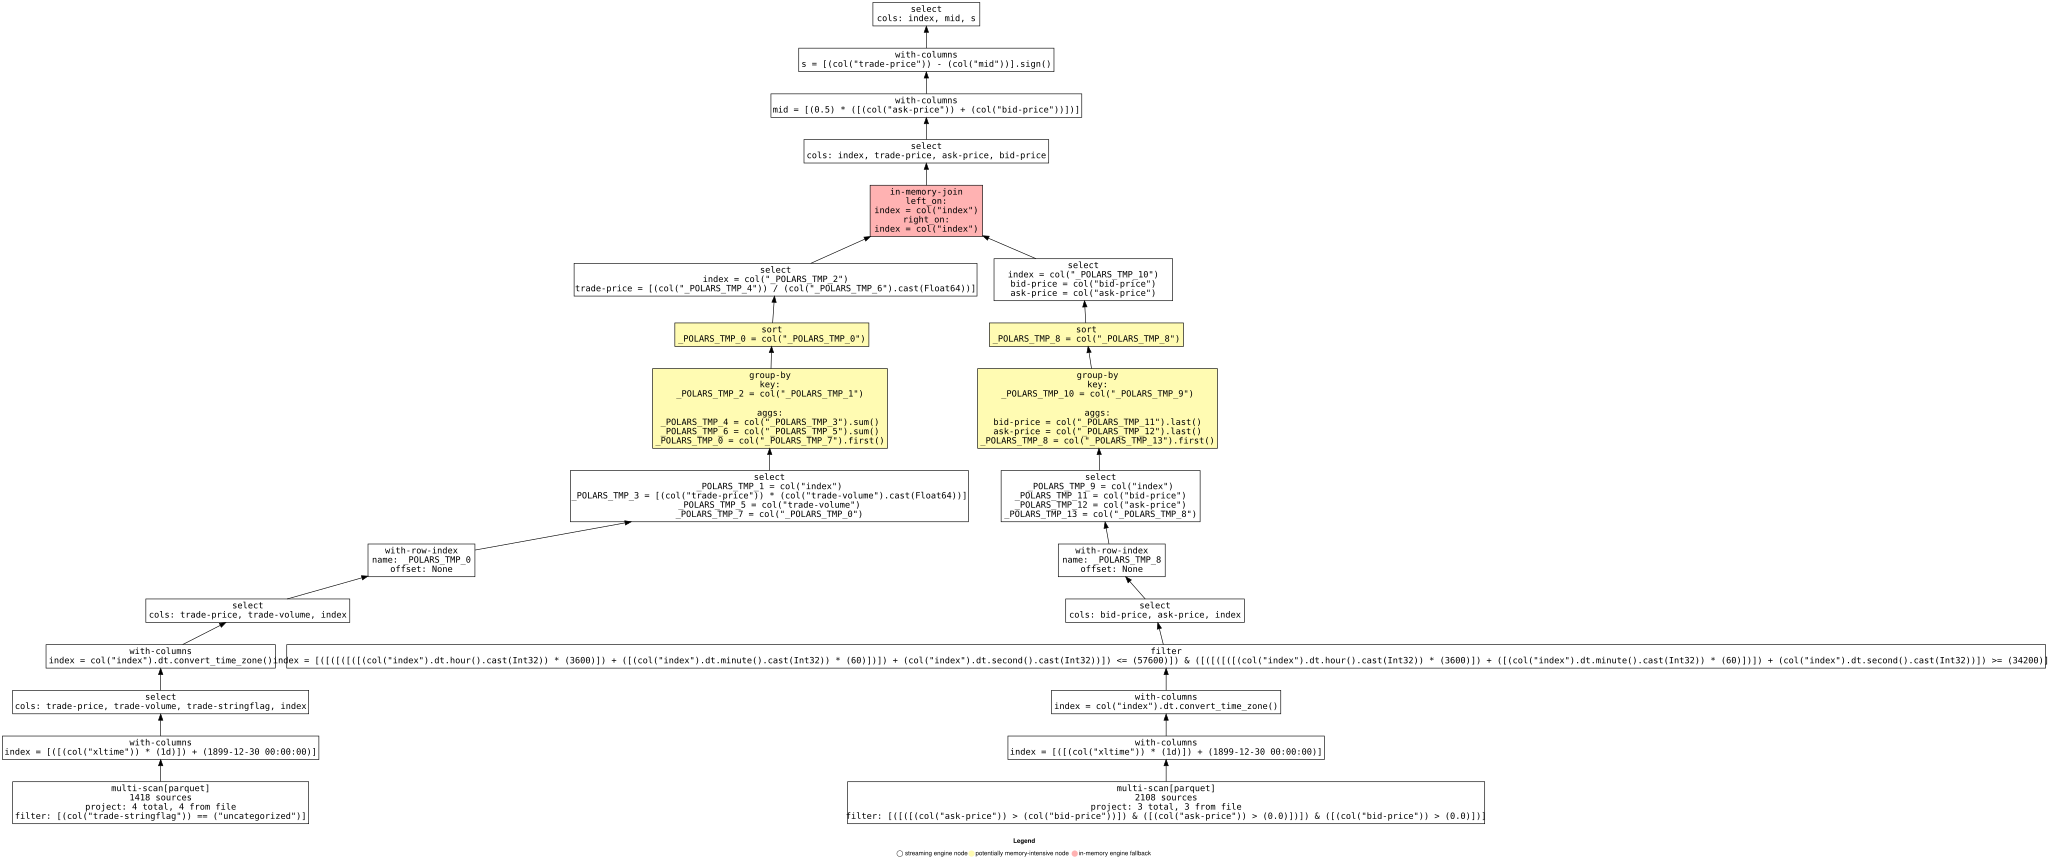

In [7]:
df_bbo = pl.scan_parquet(dirData_raw+"/bbo/"+ticker+"/*parquet")   # lazy loading
df_bbo = wrangle_bbo(df_bbo,tz_exchange="America/New_York")

df_trade = pl.scan_parquet(dirData_raw+"/trade/"+ticker+"/*parquet")   # lazy loading
df_trade = wrangle_trade(df_trade,tz_exchange="America/New_York",keep_stringflag=False)

df_events = df_trade.join_asof(df_bbo, on="index",suffix="_bbo")

df_events = df_events.with_columns((pl.col("ask-price")-pl.col("bid-price")).alias("spread"))
df_events = df_events.with_columns((0.5*(pl.col("ask-price")+pl.col("bid-price"))) .alias("mid"))
df_events = df_events.with_columns((pl.col("trade-price")-pl.col("mid")).sign().alias("s"))

smid = df_events.select(["index","mid","s"])

smid.show_graph(engine="streaming", plan_stage="physical", output_path="smid_physical.svg")



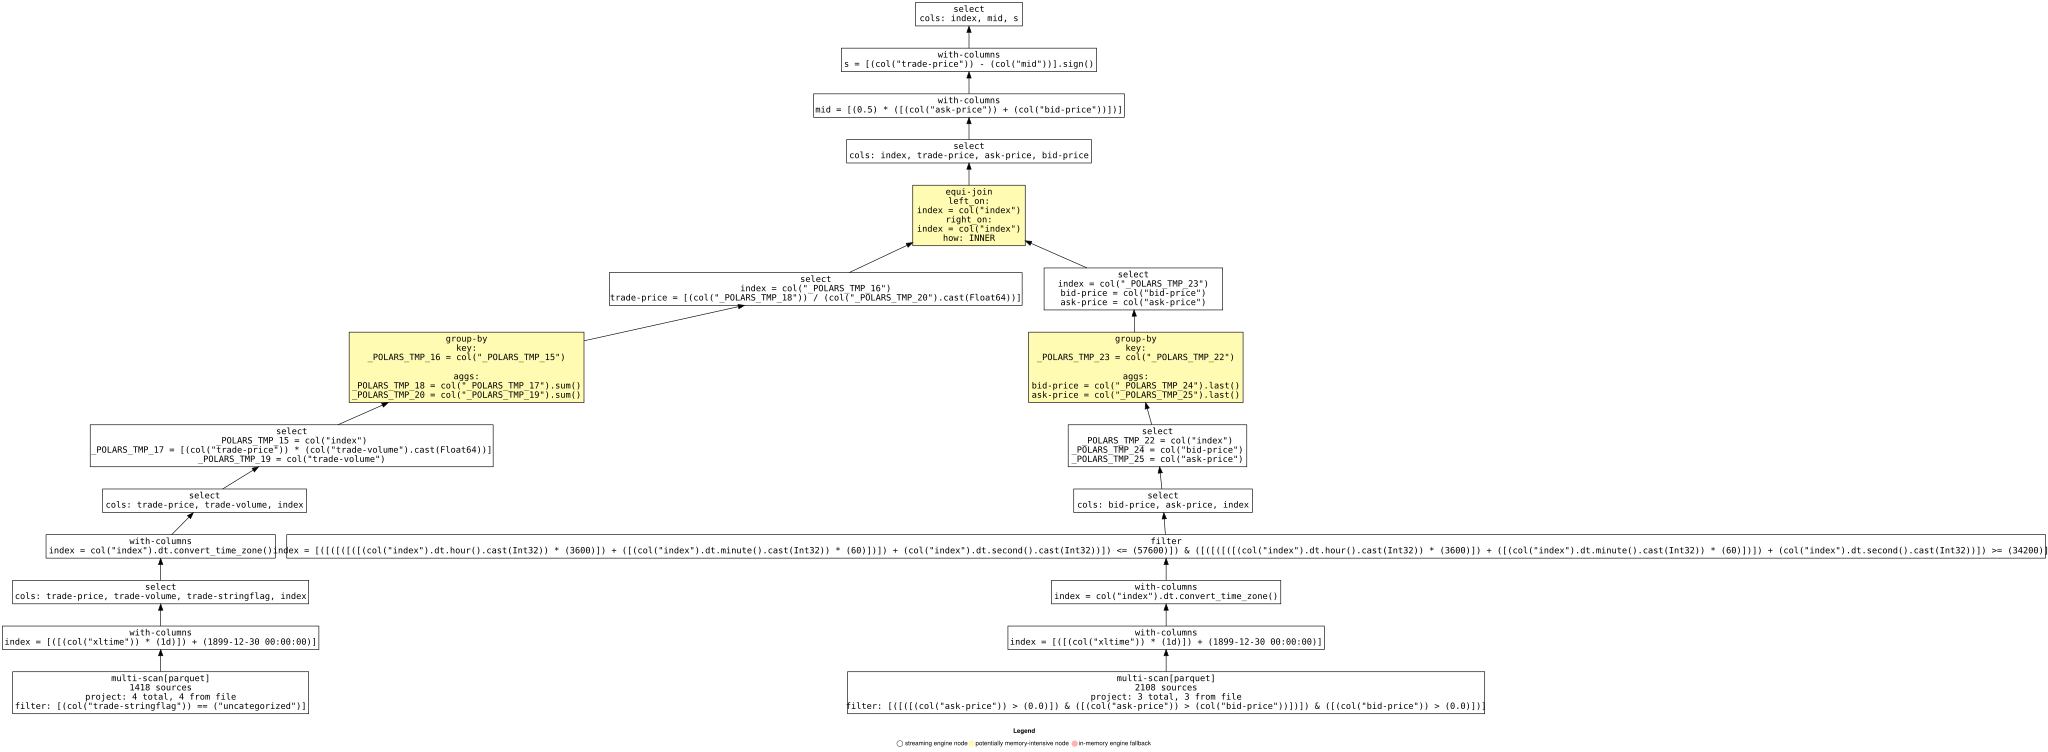

In [8]:
df_bbo = pl.scan_parquet(dirData_raw+"/bbo/"+ticker+"/*parquet")   # lazy loading
df_bbo = wrangle_bbo(df_bbo,tz_exchange="America/New_York")

df_trade = pl.scan_parquet(dirData_raw+"/trade/"+ticker+"/*parquet")   # lazy loading
df_trade = wrangle_trade(df_trade,tz_exchange="America/New_York",keep_stringflag=False)

df_events = df_trade.join(df_bbo, on="index",suffix="_bbo")

df_events = df_events.with_columns((pl.col("ask-price")-pl.col("bid-price")).alias("spread"))
df_events = df_events.with_columns((0.5*(pl.col("ask-price")+pl.col("bid-price"))) .alias("mid"))
df_events = df_events.with_columns((pl.col("trade-price")-pl.col("mid")).sign().alias("s"))

smid = df_events.select(["index","mid","s"])

smid.show_graph(engine="streaming", plan_stage="physical", output_path="smid_physical_join_inner.svg")


In [125]:
for year in range(2008,2018):
    print(year)
    year_str = str(year)
    df_bbo = pl.scan_parquet(dirData_raw+"/bbo/"+ticker+"/"+year_str+"*parquet")   # lazy loading
    df_bbo = wrangle_bbo(df_bbo,tz_exchange="America/New_York")

    df_trade = pl.scan_parquet(dirData_raw+"/trade/"+ticker+"/"+year_str+"*parquet")   # lazy loading
    df_trade = wrangle_trade(df_trade,tz_exchange="America/New_York",keep_stringflag=False)

    if not os.path.isdir(dirData_clean+"/bbo"):
        os.makedirs(dirData_clean+"/bbo")
    
    if not os.path.isdir(dirData_clean+"/trade"):
        os.makedirs(dirData_clean+"/trade")
    
    if not os.path.isdir(dirData_clean+"/events"):
        os.makedirs(dirData_clean+"/events")

    df_events = df_trade.join_asof(df_bbo, on="index",strategy="backward", suffix="_bbo")

    file_events = dirData_clean+"/events/"+ticker+"_events_"+year_str+".parquet"
    df_events.collect(engine="streaming").write_parquet(file_events)


2008
2009
2010
2011
2012
2013
2014
2015
2016
2017


In [9]:
# how to get the column names without loading the files

df_events = pl.scan_parquet(dirData_clean+"/events/"+ticker+"_events_*.parquet")
df_events.collect_schema().names()

['index',
 'trade-price',
 'trade-volume',
 'bid-price',
 'bid-volume',
 'ask-price',
 'ask-volume']

In [10]:
df_events = df_events.with_columns((pl.col("ask-price")-pl.col("bid-price")).alias("spread"))
df_events = df_events.with_columns((0.5*(pl.col("ask-price")+pl.col("bid-price"))) .alias("mid"))
df_events = df_events.with_columns((pl.col("trade-price")-pl.col("mid")).sign().alias("s"))

In [44]:
years=""
smid = df_events.select(["index","mid","s","trade-volume"])


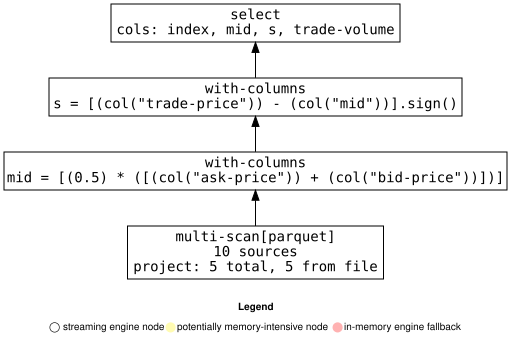

In [45]:
smid.show_graph(engine='streaming', plan_stage='physical')

In [46]:
smid.collect(engine="streaming").write_parquet(dirData_clean+"/events/"+ticker+"_smid_full.parquet")

In [13]:
smid = smid.collect()
smid

index,mid,s
"datetime[μs, America/New_York]",f64,f64
2008-08-15 09:30:00.616 EDT,129.935,-1.0
2008-08-15 09:30:00.640 EDT,129.935,-1.0
2008-08-15 09:30:00.652 EDT,129.935,1.0
2008-08-15 09:30:00.788 EDT,129.935,-1.0
2008-08-15 09:30:00.875 EDT,129.945,-1.0
…,…,…
2017-04-12 16:00:00.090999 EDT,234.1,-1.0
2017-04-12 16:00:00.099999 EDT,234.1,-1.0
2017-04-12 16:00:00.607999 EDT,234.04,NaN


In [16]:
import statsmodels.api as sm    

import matplotlib.pyplot as plt


In [ ]:

# extract series, drop NA
s = smid["s"].to_numpy()
s = s[~np.isnan(s)]
s = s[s!=0]

# compute autocorrelation (use FFT for speed on large series)
nlags = 20000
acf_vals = sm.tsa.stattools.acf(s, nlags=nlags, fft=True)


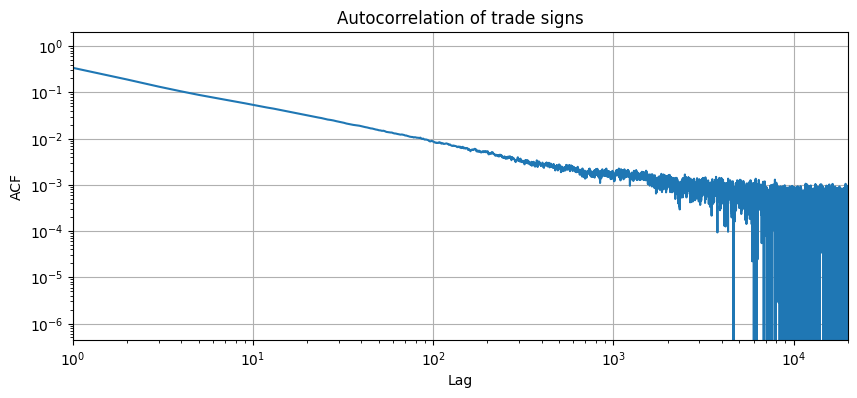

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(range(len(acf_vals)), acf_vals)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.xlim(1,len(acf_vals))
plt.title("Autocorrelation of trade signs")
plt.grid(True)
plt.xscale("log")
plt.yscale("log")
plt.savefig("sign_autocorr_SPY.pdf")
plt.show()

In [ ]:
smid = smid.with_columns(pl.col("index").dt.year().alias("year"))

acf_years = []
years = smid["year"].unique().to_list()
years.sort()
years
years = years[:-1]  # data for 2017 are incomplete

In [40]:

for year in years:
    smid_y = smid.filter(pl.col("year")==year)
    s = smid_y["s"].to_numpy()
    s = s[~np.isnan(s)]
    s = s[s!=0]

    # compute autocorrelation (use FFT for speed on large series)
    nlags = 20000
    acf_vals = sm.tsa.stattools.acf(s, nlags=nlags, fft=True)
    acf_years.append(acf_vals)




In [41]:
df_acf = pd.DataFrame(np.array(acf_years).T,columns=years)

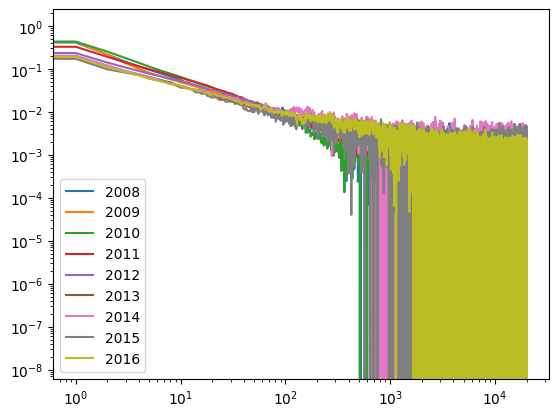

In [43]:
df_acf.plot()
plt.xscale("log")
plt.yscale("log")

plt.savefig("sign_autocorr_SPY_by_year.pdf")